In [ ]:
import numpy as np
import scipy.ndimage as ndi
import cv2
import matplotlib.pyplot as plt
#from numpy.lib.stride_tricks import sliding_window_view

Observações importantes:

Caso queira adicoinar uma nova imagem, fique a vontade. Faça a chamada dela com cv2., passe a variavel para imagem = var e depois anote o nome para que o salvamento das imagens ocorra de forma automatica na execução dos códigos.

Além disso, você irá notar trechos comentados de código em algumas funções, isso é explicado no relatório como uma mudança de metodologia que realizei por questões de eficiencia computacional.

Não esqueça de rodar a função definida logo abaixo plt_resultados() ela é responsável por exibir as imagens e gráficos e printar a porcentagem de pixels pretos.

As imagens de testes realizadas estão todas salvas em: transicoes/imagens


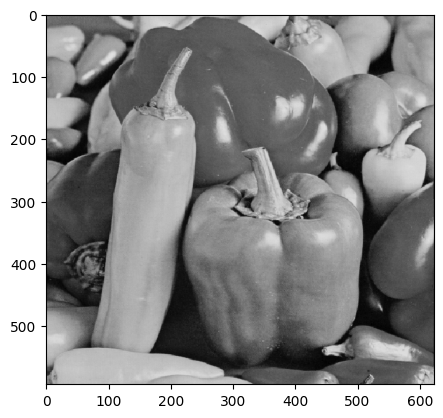

In [17]:
fiducial = cv2.imread('dataset/fiducial.pgm',cv2.IMREAD_GRAYSCALE)
retina = cv2.imread('dataset/retina.pgm',cv2.IMREAD_GRAYSCALE)
sonnet = cv2.imread('dataset/sonnet.pgm',cv2.IMREAD_GRAYSCALE)
wedge = cv2.imread('dataset/wedge.pgm',cv2.IMREAD_GRAYSCALE)
peppers = cv2.imread('dataset/peppers.pgm',cv2.IMREAD_GRAYSCALE)
monarch = cv2.imread('dataset/monarch.pgm',cv2.IMREAD_GRAYSCALE)

imagem = peppers
nome = 'peppers'

plt.imshow(imagem, cmap='gray')
plt.imsave(f'transicoes/imagens/original_{nome}.png', imagem, cmap='gray')

In [4]:

def plt_resultados(imagem_bin, imagem_cinza):
    # Cria uma figura mais larga (15 de largura, 5 de altura)
    plt.figure(figsize=(15, 5)) 

    # 1. Imagem binarizada
    plt.subplot(1, 3, 1)
    plt.imshow(imagem_bin, cmap='gray')
    plt.title('Imagem Binarizada')
    plt.axis('off')

    # 2. Histograma da imagem original
    plt.subplot(1, 3, 2)
    plt.hist(imagem_cinza.ravel(), bins=256, range=[0, 256], color='gray', alpha=0.7)
    plt.title('Histograma (Original)')
    plt.xlabel('Intensidade')
    plt.ylabel('Frequência')

    # 3. Histograma da imagem binarizada
    plt.subplot(1, 3, 3)
    plt.hist(imagem_bin.ravel(), bins=256, range=[0, 256], color='black', alpha=0.7)
    plt.title('Histograma (Binarizada)')
    plt.xlabel('Intensidade')
    plt.ylabel('Frequência')

    # tight_layout agora terá espaço suficiente para organizar os elementos
    print("Resultados da binarização:")
    plt.tight_layout()
    plt.show()
    print("Fração de pixel pretos (0):", np.sum(imagem_bin == 0)/imagem_bin.size)

Método Global

Resultados da binarização:


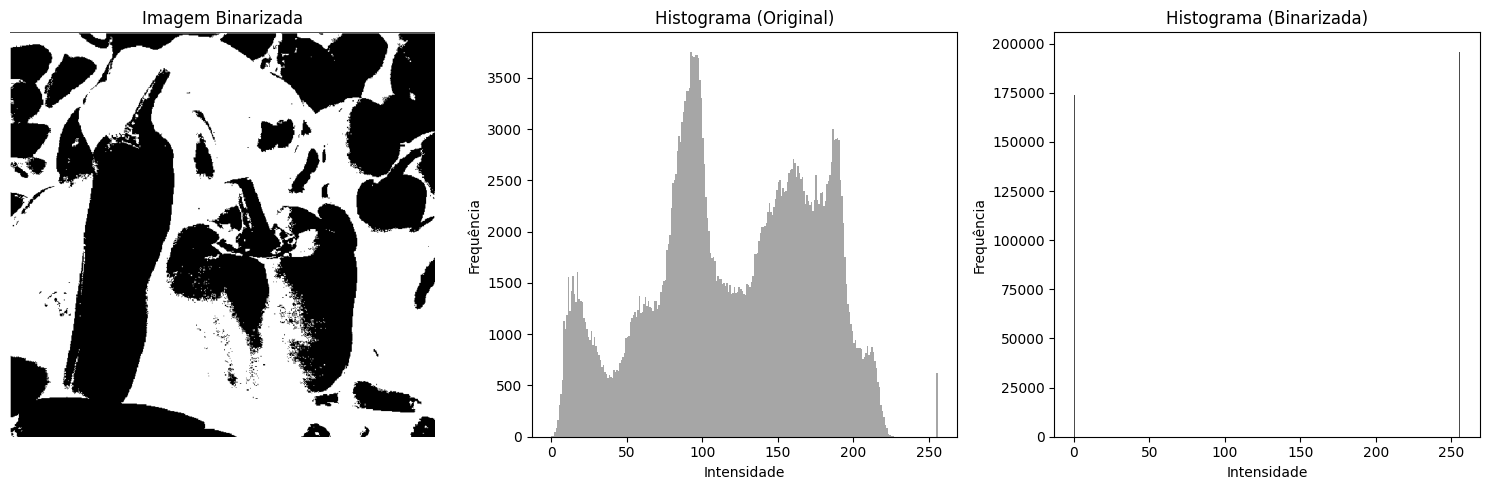

Fração de pixel pretos (0): 0.4704698131664424


In [22]:
T = 128

imagem_nova = imagem.copy()

imagem_nova[imagem <= T] = 255
imagem_nova[imagem > T] = 0

plt_resultados(imagem_nova, imagem)

plt.imsave(f'transicoes/imagens/global_{nome}_{T}.png', imagem_nova, cmap='gray')


Método de Otsu

Resultados da binarização:


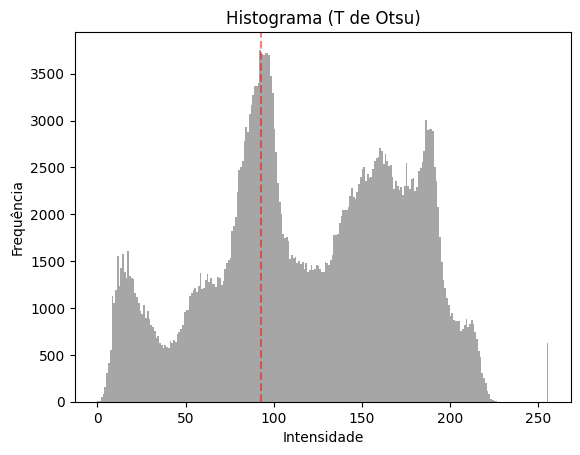

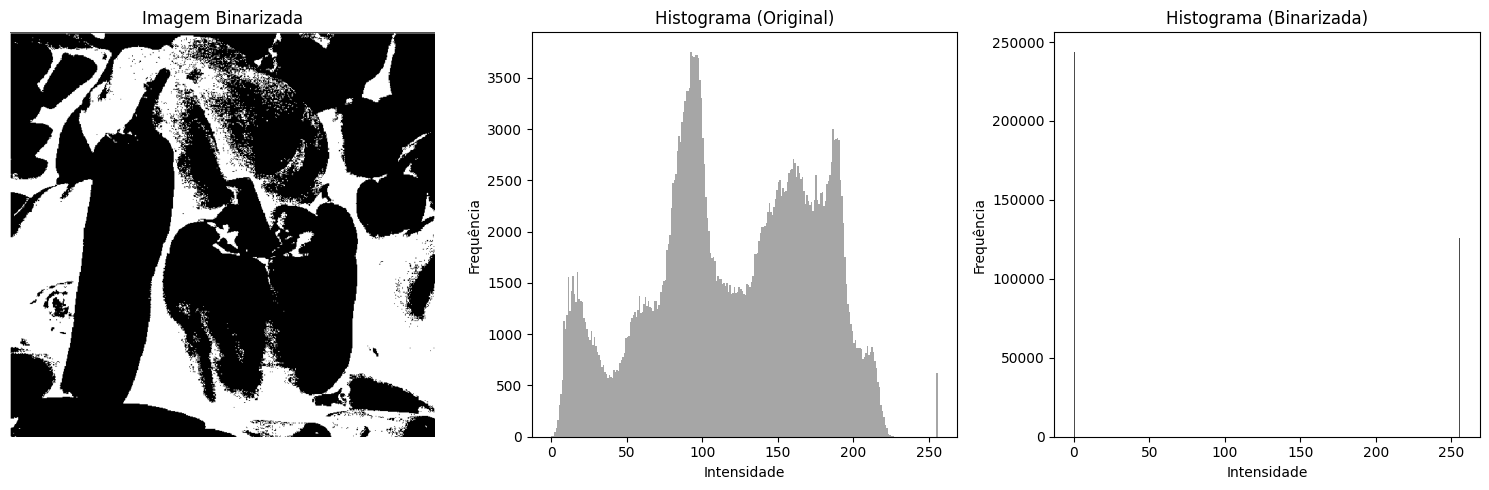

Fração de pixel pretos (0): 0.6592516929595581


In [18]:
hist = cv2.calcHist([imagem], [0], None, [256], [0, 256])
hist.ravel()
max_var = 0
optimal_threshold = 0
for i in range(255):
    w0 = hist[:i].sum()
    w1 = hist[i:].sum()

    u0 = (hist[:i] * np.arange(i)).sum() / w0 if w0 > 0 else 0
    u1 = (hist[i:] * np.arange(i, 256)).sum() / w1 if w1 > 0 else 0

    var_between = w0 * w1 * (u0 - u1) ** 2
    if var_between > max_var:
        max_var = var_between
        optimal_threshold = i   


imagem_otsu = imagem.copy()
imagem_otsu[imagem <= optimal_threshold] = 255
imagem_otsu[imagem > optimal_threshold] = 0

plt.hist(imagem.ravel(), bins=256, range=[0, 256], color='gray', alpha=0.7)
plt.axvline(x=optimal_threshold, color='red', linestyle='--', alpha=0.5)
plt.title('Histograma (T de Otsu)')
plt.xlabel('Intensidade')
plt.ylabel('Frequência')
plt_resultados(imagem_otsu, imagem)
plt.imsave(f'transicoes/imagens/otsu_{nome}.png', imagem_otsu, cmap='gray')

Metodo de Bernsen

Resultados da binarização:


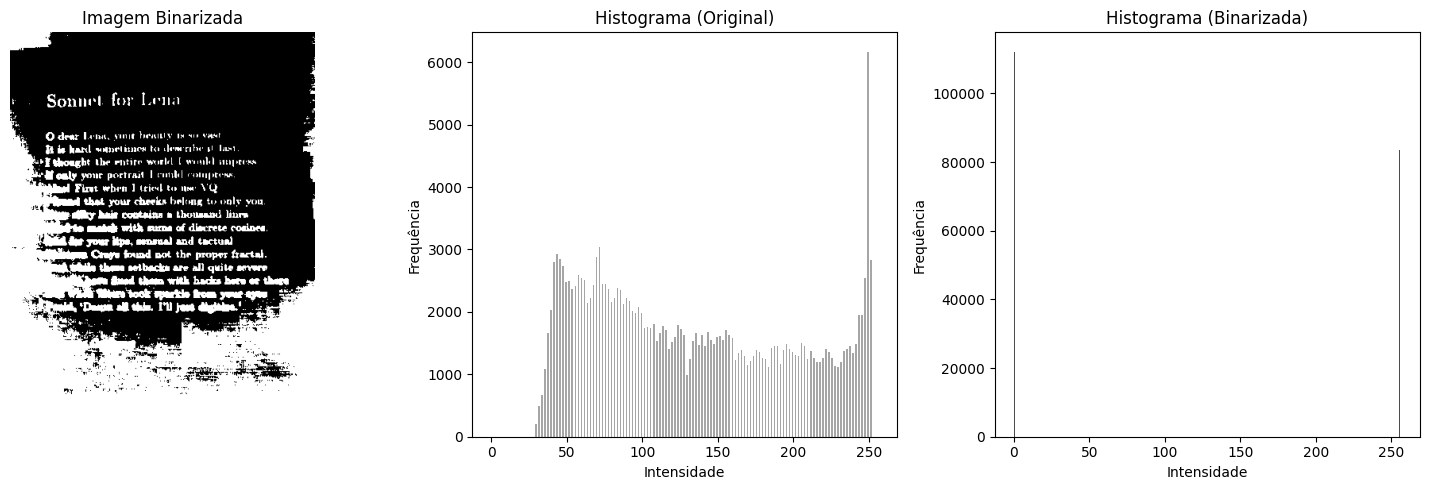

Fração de pixel pretos (0): 0.5728451797385621


In [ ]:
imagem_bernsen = imagem.copy()
n = 121

def bernsen_manual_vetorizado(img, n):
    #pad = n // 2
    
    #img_padded = np.pad(img, pad_width=pad, mode='reflect')
    
    #windows = sliding_window_view(img_padded, window_shape=(n, n))
    
    #z_min = np.min(windows, axis=(2, 3)).astype(np.float32)
    #z_max = np.max(windows, axis=(2, 3)).astype(np.float32)

    z_min = ndi.minimum_filter(img, size=n).astype(np.float32)
    z_max = ndi.maximum_filter(img, size=n).astype(np.float32)
    
    T_bernsen = (z_min + z_max) / 2.0
    
    resultado = np.where(img > T_bernsen, 0, 255).astype(np.uint8)
    
    return resultado

imagem_bernsen = bernsen_manual_vetorizado(imagem_bernsen, n)

plt_resultados(imagem_bernsen, imagem)
plt.imsave(f'transicoes/imagens/bernsen_{nome}_{n}.png', imagem_bernsen, cmap='gray')


Metodo de Niblack 

(384, 507)
Resultados da binarização:


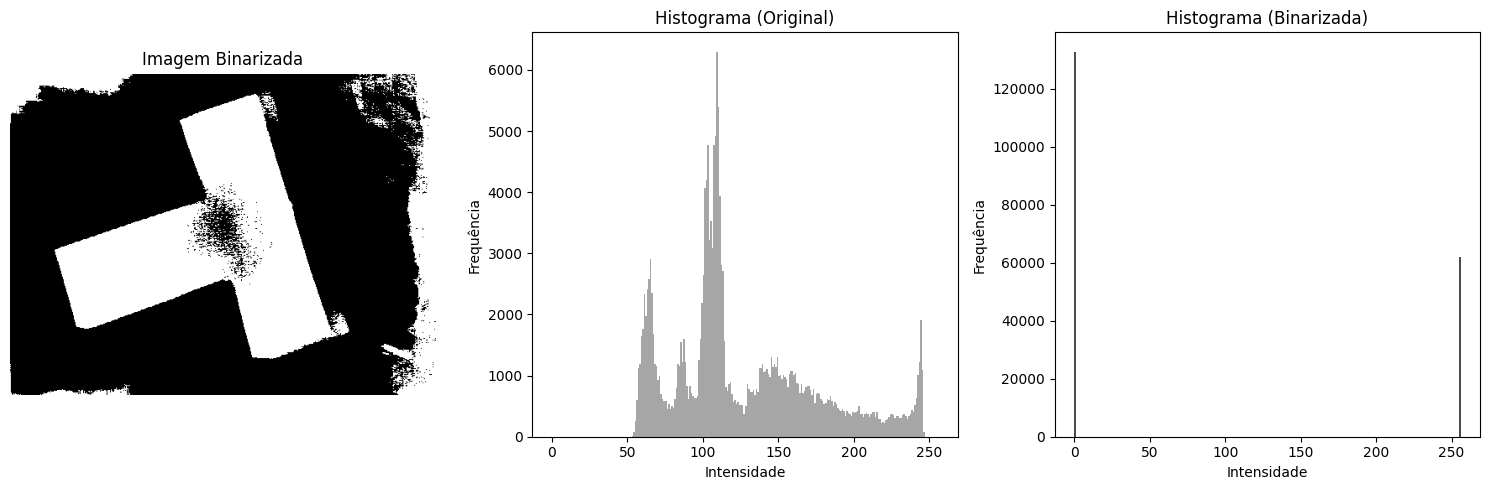

Fração de pixel pretos (0): 0.6822505752794215


In [62]:
imagem_nil = imagem.copy()
n = 161
k = -0.45
print(imagem_nil.shape)

def nil_manual_vetorizado(img, n, k):
    #pad = n // 2
    #img_padded = np.pad(img, pad_width=pad, mode='reflect')
    #windows = sliding_window_view(img_padded, window_shape=(n, n))
    
    #mean = np.mean(windows, axis=(2, 3)).astype(np.float32)
    #std = np.std(windows, axis=(2, 3)).astype(np.float32)

    img_f = img.astype(np.float32)
    
   
    mean = ndi.uniform_filter(img_f, size=n)
    
    mean_sq = ndi.uniform_filter(img_f**2, size=n)
    
    std = np.sqrt(np.maximum(mean_sq - mean**2, 0))
    
    T_nil = mean + std*k
    
    resultado = np.where(img > T_nil, 0, 255).astype(np.uint8)
    
    return resultado

imagem_nil = nil_manual_vetorizado(imagem_nil, n, k)
plt_resultados(imagem_nil, imagem)
plt.imsave(f'transicoes/imagens/nil_{nome}_{n}_{k}.png', imagem_nil, cmap='gray')

Metodo de Sauvola e Pietaksinen

Resultados da binarização:


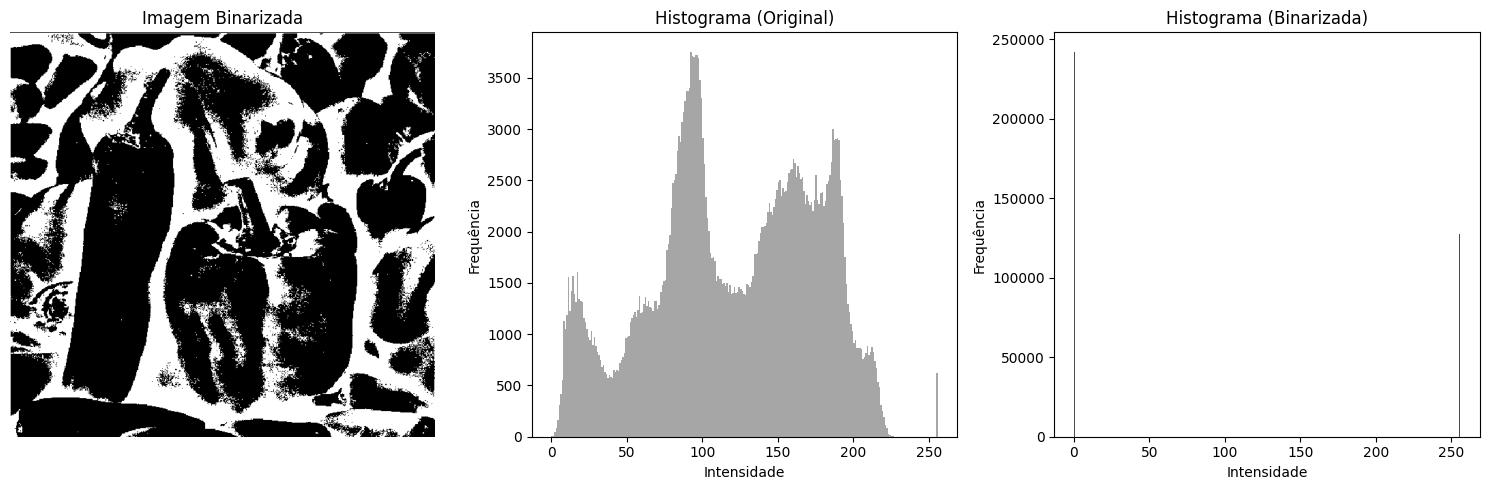

Fração de pixel pretos (0): 0.654852430133329


In [21]:
imagem_SP = imagem.copy()
n = 71
k = 0.1
R = 128

def SP_manual_vetorizado(img, n, k, R):
    #pad = n // 2
    #img_padded = np.pad(img, pad_width=pad, mode='reflect')
    #windows = sliding_window_view(img_padded, window_shape=(n, n))
    
    #mean = np.mean(windows, axis=(2, 3)).astype(np.float32)
    #std = np.std(windows, axis=(2, 3)).astype(np.float32)

    img_f = img.astype(np.float32)
    
   
    mean = ndi.uniform_filter(img_f, size=n)
    
    mean_sq = ndi.uniform_filter(img_f**2, size=n)
    
    std = np.sqrt(np.maximum(mean_sq - mean**2, 0))
    
    T_SP = mean * ( 1 + k*(std/R - 1))
    
    resultado = np.where(img > T_SP, 0, 255).astype(np.uint8)
    
    return resultado

imagem_SP = SP_manual_vetorizado(imagem_SP, n, k, R)
plt_resultados(imagem_SP, imagem)
plt.imsave(f'transicoes/imagens/SP_{nome}_{n}_{k}_{R}.png', imagem_SP, cmap='gray')

Metodo de Phansalskar, More e Sabale

Resultados da binarização:


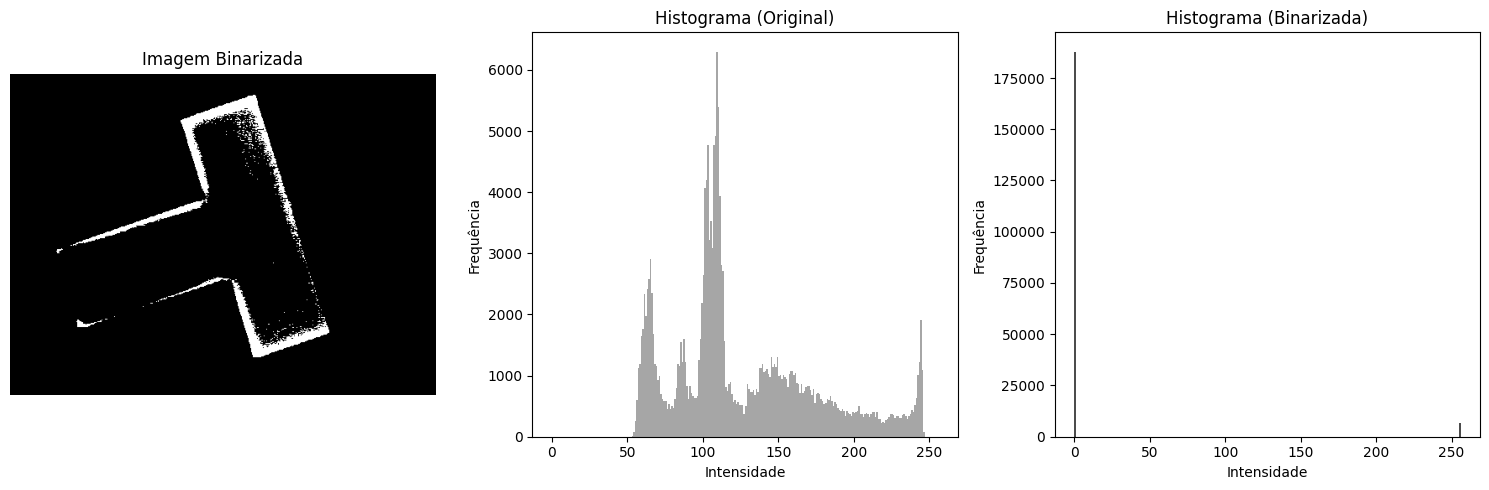

Fração de pixel pretos (0): 0.965067184418146


In [100]:
imagem_PMS = imagem.copy()
n = 31
k = 0.25
R = 0.5
q = 10
p = 2

def PMS_manual_vetorizado(img, n, k, R, p, q):

    img_norm = img.astype(np.float32) / 255.0

    #pad = n // 2
    #img_padded = np.pad(img_norm, pad_width=pad, mode='reflect')
    #windows = sliding_window_view(img_padded, window_shape=(n, n))
    
    #mean = np.mean(windows, axis=(2, 3)).astype(np.float32)
    #std = np.std(windows, axis=(2, 3)).astype(np.float32)

    img_f = img_norm.astype(np.float32)
    
   
    mean = ndi.uniform_filter(img_f, size=n)
    
    mean_sq = ndi.uniform_filter(img_f**2, size=n)
    
    std = np.sqrt(np.maximum(mean_sq - mean**2, 0))
    
    T_PMS = mean * ( 1 + p*np.exp(-q*mean) + k*(std/R - 1))
    
    resultado = np.where(img_norm > T_PMS, 0, 255).astype(np.uint8)
    
    return resultado

imagem_PMS = PMS_manual_vetorizado(imagem_PMS, n, k, R, p ,q)
plt_resultados(imagem_PMS, imagem)
plt.imsave(f'transicoes/imagens/PMS_{nome}_{n}_{k}_{R}_{p}_{q}.png', imagem_PMS, cmap='gray')

Metodo do Contraste

Resultados da binarização:


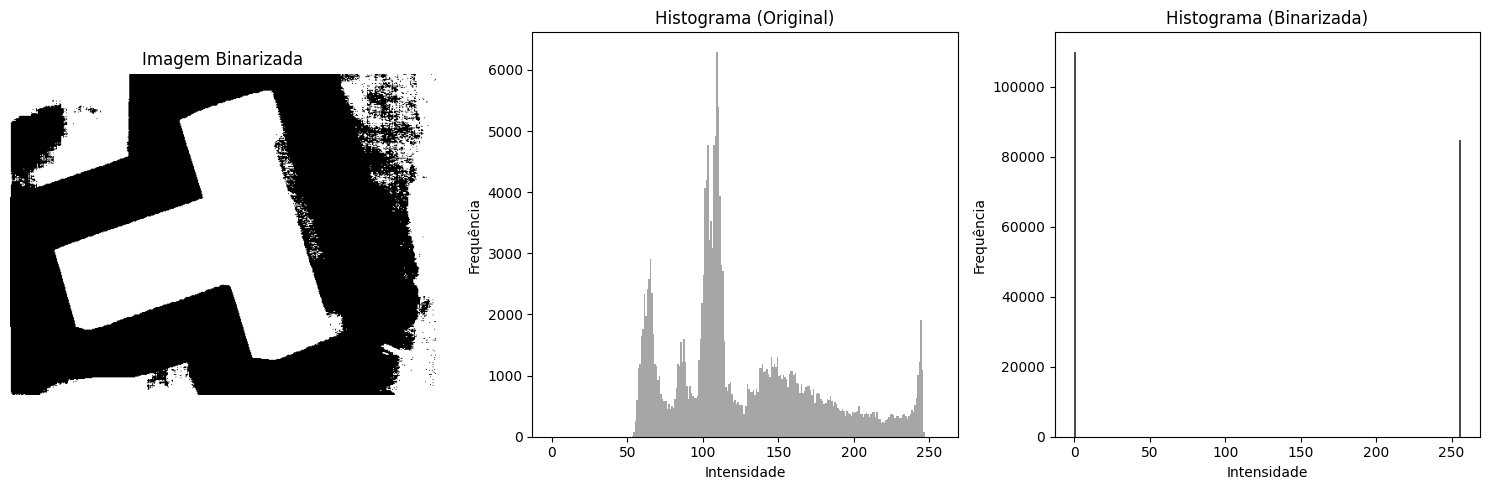

Fração de pixel pretos (0): 0.5651452580539119


In [102]:
imagem_contraste = imagem.copy()
n = 121

def contraste_manual_vetorizado(img, n):
    #pad = n // 2
    #img_padded = np.pad(img, pad_width=pad, mode='reflect')
    #windows = sliding_window_view(img_padded, window_shape=(n, n))
    
    #z_max = np.max(windows, axis=(2, 3)).astype(np.float32)
    #z_min = np.min(windows, axis=(2, 3)).astype(np.float32)

    z_min = ndi.minimum_filter(img, size=n).astype(np.float32)
    z_max = ndi.maximum_filter(img, size=n).astype(np.float32)

    i = img.astype(np.float32)
    
    dist_max = z_max - i
    dist_min = i - z_min
    
    resultado = np.where(dist_max <= dist_min, 0, 255).astype(np.uint8)
    
    return resultado

imagem_contraste = contraste_manual_vetorizado(imagem_contraste, n)
plt_resultados(imagem_contraste, imagem)
plt.imsave(f'transicoes/imagens/contraste_{nome}_{n}.png', imagem_contraste, cmap='gray')

Metodo da Média

Resultados da binarização:


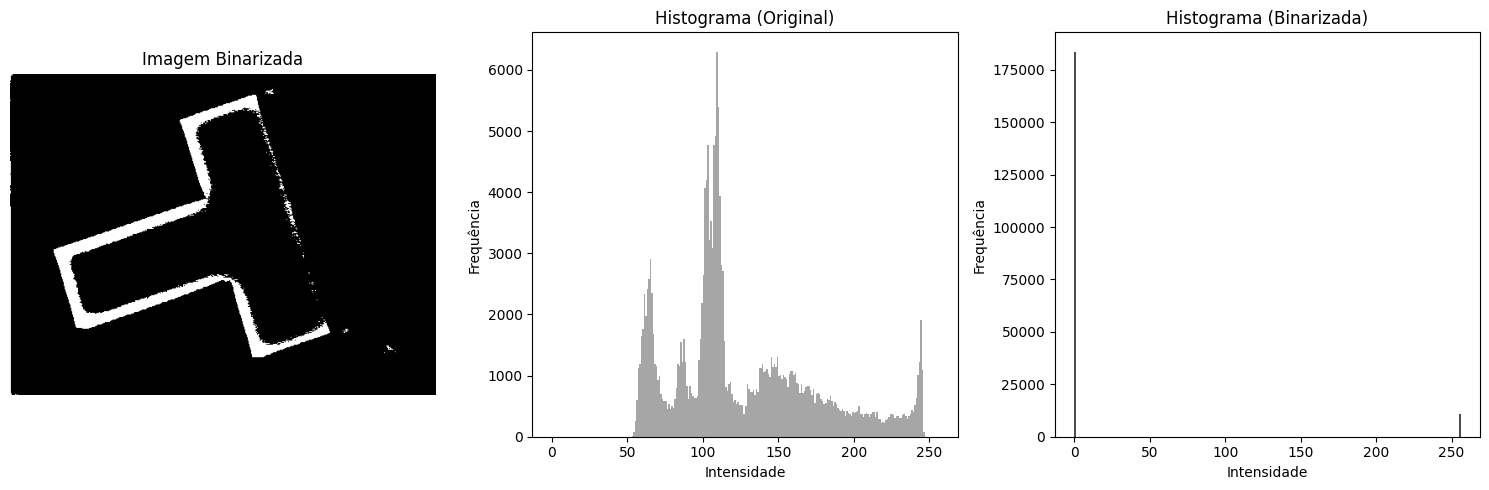

Fração de pixel pretos (0): 0.9432579306377383


In [103]:
imagem_media = imagem.copy()
n = 41
C = 10
def media_manual_vetorizado(img, n, C):
    #pad = n // 2
    #img_padded = np.pad(img, pad_width=pad, mode='reflect')
    #windows = sliding_window_view(img_padded, window_shape=(n, n))
    
    #mean = np.mean(windows, axis=(2, 3)).astype(np.float32)
    
    mean = ndi.uniform_filter(img.astype(np.float32), size=n)
    
    T_mean = mean - C
    resultado = np.where(img > T_mean, 0, 255).astype(np.uint8)
    
    return resultado

imagem_media = media_manual_vetorizado(imagem_media, n, C)
plt_resultados(imagem_media, imagem)
plt.imsave(f'transicoes/imagens/media_{nome}_{n}_{C}.png', imagem_media, cmap='gray')

Método da Mediana

Resultados da binarização:


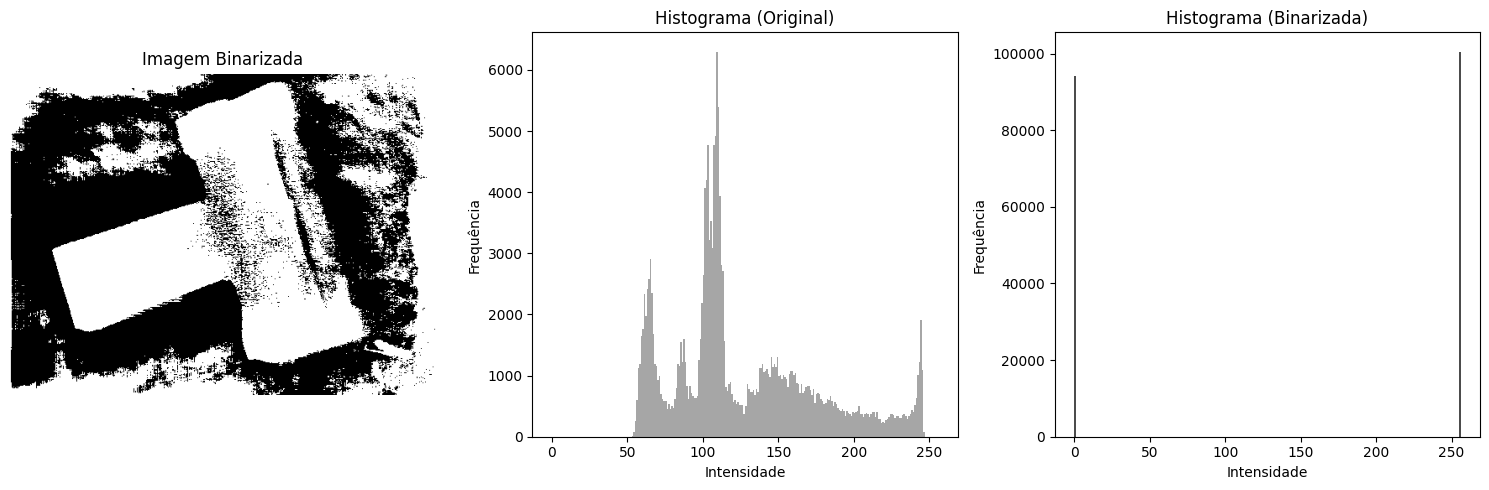

Fração de pixel pretos (0): 0.4837945841551611


In [105]:
imagem_mediana = imagem.copy()
n = 121
def mediana_manual_vetorizado(img, n):
    #pad = n // 2
    #img_padded = np.pad(img, pad_width=pad, mode='reflect')
    #windows = sliding_window_view(img_padded, window_shape=(n, n))
    
    #median = np.median(windows, axis=(2, 3)).astype(np.float32)
    
    median = ndi.median_filter(img.astype(np.float32), size=n)

    T_median = median
    resultado = np.where(img > T_median, 0, 255).astype(np.uint8)
    
    return resultado

imagem_mediana = mediana_manual_vetorizado(imagem_mediana, n)
plt_resultados(imagem_mediana, imagem)
plt.imsave(f'transicoes/imagens/mediana_{nome}_{n}.png', imagem_mediana, cmap='gray')